In [1]:
import torch
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

from dataset import NNUEIterableDataset

In [2]:
dataloader = DataLoader(
    NNUEIterableDataset("../data/nnue/train", batch_size=1000, random_hflip=False, hflip=False),
    batch_size=None,
    num_workers=2,
    persistent_workers=True,
    prefetch_factor=4,
)

flip_dataloader = DataLoader(
    NNUEIterableDataset("../data/nnue/train", batch_size=1000, random_hflip=False, hflip=True),
    batch_size=None,
    num_workers=2,
    persistent_workers=True,
    prefetch_factor=4,
)

In [3]:
buckets = np.linspace(-10000, 10000, 100)
counts = np.zeros(100)
wins = np.zeros(100)

idx_counts = np.zeros(2344)

for (batch, flip_batch) in zip(dataloader, flip_dataloader):
    b, w, s, r, t = batch

    flip_b, flip_w, flip_s, flip_r, flip_t = flip_batch

    b = torch.cat([b, flip_b], dim=0)
    w = torch.cat([w, flip_w], dim=0)
    s = torch.cat([s, flip_s], dim=0)
    r = torch.cat([r, flip_r], dim=0)
    t = torch.cat([t, flip_t], dim=0)

    np.add.at(idx_counts, b.flatten(), 1)
    np.add.at(idx_counts, w.flatten(), 1)

    s = np.clip(s, -10000, 10000)

    # digitize returns the indices of the buckets [1, ..., len(buckets)]
    bin_indices = np.digitize(s, buckets) - 1  # Shift to zero-indexed

    # keep only scores that fell within the buckets
    mask = (bin_indices >= 0) & (bin_indices < len(buckets))
    bin_indices = bin_indices[mask]
    r_valid = r[mask]

    # Update counts and wins per bucket
    for idx, result in zip(bin_indices, r_valid):
        counts[idx] += 1
        wins[idx] += result

total = counts.sum() / 2 # remove the flip counts
print(f'total: {total.item()}')

perf = wins / counts

total: 20240000.0


In [4]:
buckets = buckets / (127*64)

In [5]:
targets = torch.sigmoid(torch.tensor(buckets*4)).numpy()

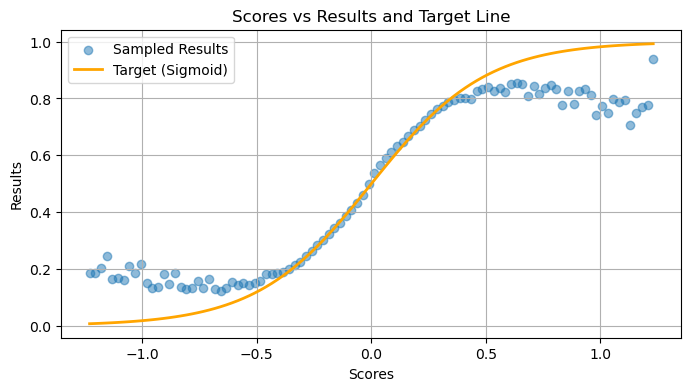

In [6]:
plt.figure(figsize=(8, 4))
plt.scatter(buckets, perf, alpha=0.5, label='Sampled Results')
plt.plot(buckets, targets, color='orange', label='Target (Sigmoid)', linewidth=2)

plt.xlabel('Scores')
plt.ylabel('Results')
plt.title('Scores vs Results and Target Line')
# plt.xlim(-10000, 10000)
plt.grid(True)
plt.legend()
plt.show()

In [7]:
empty_idxs = np.where(idx_counts == 0)[0]
print(f'{empty_idxs.shape[0]} empty features')
print(f'{empty_idxs.shape[0] - (9*4*2)} after removing impossible features')
for idx in empty_idxs:
    print(idx)


92 empty features
20 after removing impossible features
243
244
245
246
247
248
249
250
251
324
325
326
327
328
329
330
331
332
333
334
335
336
337
338
339
340
341
567
568
569
570
571
572
573
574
575
721
722
723
725
726
727
804
805
806
886
1449
1450
1451
1452
1453
1454
1455
1456
1457
1521
1522
1523
1524
1525
1526
1527
1528
1529
1530
1531
1532
1533
1534
1535
1536
1537
1538
1773
1774
1775
1776
1777
1778
1779
1780
1781
1783
1784
1785
1787
1788
1789
1866
1867
1868
1948
